In [1]:
import json
import networkx as nx
from networkx.readwrite import json_graph
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
import os
import pickle
from PIL import Image
import itertools

In [2]:
def load_graph_from_json(plan):
    with open(f'data/{plan}/graph_output.json', 'r') as f:
        data = json.load(f)

    G = json_graph.node_link_graph(
        data,
        edges='links',
    )

    image = Image.open(f'Data/{plan}/output/graph_on_input.png')

    with open(f'data/{plan}/output/model_processed.pkl', 'rb') as f:
        room_masks = pickle.load(f)
    first_key = next(iter(room_masks))
    mask_shape = room_masks[first_key][0].shape
    target_h, target_w = mask_shape[:2]
    image = image.resize( (target_w, target_h))

    return G, image

def graph_generator():
    '''Yield all graphs and their corresponding images from the data directory.
    '''
    subfolders= [f.path.split('/')[-1] for f in os.scandir('Data/') if f.is_dir()]
    for plan in sorted(subfolders):
        G, image = load_graph_from_json(plan)
        yield plan, G, image

def plot(G, im=None):
    '''Plot the graph G with optional background image im.'''
    pos = {
        node: tuple(data['position'])
        for node, data in G.nodes(data=True)
    }
    nodes_colours = []
    for _, data in G.nodes(data=True):
        if data['room_name'] == 'door':
            nodes_colours.append('#0084FF')
        elif data['room_name'] == 'exit_door':
            nodes_colours.append('#00FF00')
        else:
            nodes_colours.append('#FF00AA')
    edges_colours = []
    for _, _, connection in G.edges.data('connection'):
        if connection == 'door':
            edges_colours.append('#0084FF')
        elif connection == 'adjacent':
            edges_colours.append('#FF00AA')
        else:
            edges_colours.append('#0F0F0F')


    plt.figure(figsize=(8, 8))
    if im is not None:
        plt.imshow(im)
    nx.draw_networkx(G, pos=pos, with_labels=True, font_size=8, node_color=nodes_colours, node_size=300, edge_color=edges_colours, width=4
    )

In [9]:
# Make a NetworkX graph from a node-link JSON file. Also extract the floorplan base image and resize it.
def MakeGraph2(plan,Out=True):
    with open(f'data/{plan}/graph_output.json', 'r') as f:
        data = json.load(f)

    # Make the graph
    G = json_graph.node_link_graph(data, edges='links')
    
    # Add the Outside as a node, connecting to exterior doors, if desired.
    if Out:
        ExDoors = [node2 for _,node2,dat in G.edges(data=True) if dat['connection']=='exit']
        G.add_node('Outside', room_id='-1', room_name='Outside', room_size=1, position=(0,0))
        G.add_edges_from([(Door, 'Outside') for Door in ExDoors], connection='exit')

    image = Image.open(f'Data/{plan}/output/graph_on_input.png')

    # Obtain the floorplan image and resize it as necessary.
    with open(f'data/{plan}/output/model_processed.pkl', 'rb') as f:
        room_masks = pickle.load(f)
    first_key = next(iter(room_masks))
    mask_shape = room_masks[first_key][0].shape
    target_h, target_w = mask_shape[:2]
    image = image.resize( (target_w, target_h))

    return G, image

# Get each folder name for the data.
def graph_generator():
    '''Yield all graphs and their corresponding images from the data directory.'''
    subfolders= [f.path.split('/')[-1] for f in os.scandir('Data/') if f.is_dir()]
    for plan in sorted(subfolders):
        G, image = MakeGraph2(plan,False)
        GOut, image = MakeGraph2(plan)
        yield plan, G, GOut

# Plot the graph.
def GraphPlot(G, plan, im=None, Save=False):
    
    ExDoors = [node2 for _,node2,dat in G.edges(data=True) if dat['connection']=='exit']
    pos = {node: tuple(data['position']) for node, data in G.nodes(data=True)}
    NodeColours = ['lime' if node=='Outside' else 'magenta' if node in ExDoors else 'tab:red' if dat['room_name']=='door' else 'tab:blue' for node,dat in G.nodes(data=True)]
    EdgeColours = ['lime' if (node1=='Outside' or node2=='Outside') else 'tab:red' if ('door' in node2 and 'door' not in node1) else 'tab:blue' for node1,node2,dat in G.edges(data=True)]
    
    plt.figure(figsize=(8,8))
    if im is not None:
        plt.imshow(im)
    nx.draw_networkx(G, pos=pos, with_labels=True, node_size=300, node_color=NodeColours, edge_color=EdgeColours, width=3, font_size=6)
    
    # Node legend
    node_handles = [
        mlines.Line2D([], [], color='tab:red', marker='o', linestyle='None', markersize=10, label='Door'),
        mlines.Line2D([], [], color='magenta', marker='o', linestyle='None', markersize=10, label='Exit Door'),
        mlines.Line2D([], [], color='tab:blue', marker='o', linestyle='None', markersize=10, label='Room'),
        mlines.Line2D([], [], color='lime', marker='o', linestyle='None', markersize=10, label='Outside'),
    ]
    # Edge legend
    edge_handles = [
        mlines.Line2D([], [], color='tab:red', linewidth=4, label='Door Connection'),
        mlines.Line2D([], [], color='tab:blue', linewidth=4, label='Adjacent'),
        mlines.Line2D([], [], color='lime', linewidth=4, label='Outside Connection'),
    ]
    plt.legend(handles=node_handles + edge_handles, loc='best',frameon=True)
    
    plt.axis('equal')
    if Save:
        plt.savefig(f'Data/{plan}/output/graph_on_input_new.png', dpi=500)
    plt.show()

# Removes adjacency connections.
def RemoveAdjacency(G):
    # Remove adjacency edges.
    GDoors = G.copy()
    GDoors.remove_edges_from([[u,v] for u,v in list(G.edges()) if ('door' not in u and 'door' not in v)])
    return GDoors

# Check if two doors connect the same pair of rooms.
def TwoDoors(G):
    doorNodes = [node for node,data in G.nodes(data=True) if data['room_name'] == 'door']
    Dupes = 0
    for door1, door2 in itertools.combinations(doorNodes, 2):
        if len(nx.common_neighbors(G, door1, door2)) == 2:
            Dupes += 1

    return Dupes
    
# Check which doors are too near to each other.
def DoorDupes(G,eps=10):
    doorsPos = np.array([dat['position'] for _,dat in G.nodes(data=True) if 'door' in dat['room_name']])
    Dupes = 0
    for i in range(len(doorsPos)-1):
        doorDist = np.array([np.linalg.norm(x) for x in doorsPos[i+1:]-doorsPos[i]])
        if any(doorDist<eps):
            Dupes += 1
            
    return Dupes

# Check that doors have the right connections, and that rooms have doors.
def SensibleConnections(G):
    # Check all doors have the right number of connections.
    dodgyDoors = 0
    for roomDat in G.nodes(data=True):
        node, room = roomDat
        if room['room_name']=='door':
            Exits = 0
            Interiors = 0
            Adjacencies = 0
            for linkDat in G.edges(data=True):
                u,v, link = linkDat
                if u==node or v==node:
                    if link['connection']=='exit':
                        Exits+=1
                    elif link['connection']=='door':
                        Interiors+=1
                    else:
                        Adjacencies+=1
            if (Adjacencies>0) or (Exits>0 and Interiors>0) or (Exits>1 and Interiors==0) or (Exits==0 and (Interiors==1 or Interiors>2)) or (Exits==0 and Interiors==0 and Adjacencies==0):
                dodgyDoors += 1

    # Check every room has a door on it.
    dodgyRooms = 0
    for room in G.nodes():
        if 'door' not in room:
            if not any('door' in neighbour for neighbour in list(nx.all_neighbors(G, room))):
                dodgyRooms += 1
    
    return dodgyDoors, dodgyRooms

def check_all(eps=10, plot_failed=False):
    n_failed = 0
    n_passed = 0
    for plan, G, GOut in graph_generator():
        H = RemoveAdjacency(GOut)
        
        msg = f'{plan=}'
        failed = 0

        # Run checks on graph.
        if not nx.is_connected(H):
            msg += ' | Not connected'
            failed += 1
        if not nx.is_planar(H):
            msg += ' | Not planar'
            failed += 1
        Dupes1 = TwoDoors(H)
        if Dupes1>0:
            msg += f' | {Dupes1} set(s) of paired doors'
            failed += 1
        Dupes2 = DoorDupes(H)
        if Dupes2>0:
            msg += f' | {Dupes2} set(s) of duplicated doors'
            failed += 1
        dodgyDoors, dodgyRooms = SensibleConnections(G)
        if dodgyDoors>0:
            msg += f' | {dodgyDoors} door(s) with incorrect connections'
            failed += 1
        if dodgyRooms>0:
            msg += f' | {dodgyRooms} room(s) without a door'
            failed += 1
        
        # Check if the test failed and output the message.
        if failed>0:
            msg += f' | {failed} test(s) failed'
            n_failed += 1
        else:
            msg += ' | No problems detected'
            n_passed += 1
        print(msg)
    
    # Print proportion of failed graphs.
    print(n_failed/len(list(graph_generator())) * 100, f'% of {n_passed+n_failed} plans failed checks')

In [4]:
check_all()

plan='10108' | Not connected | 1 room(s) without a door | 2 test(s) failed
plan='10218' | 2 set(s) of paired doors | 2 set(s) of duplicated doors | 2 test(s) failed
100.0 % of 2 plans failed checks


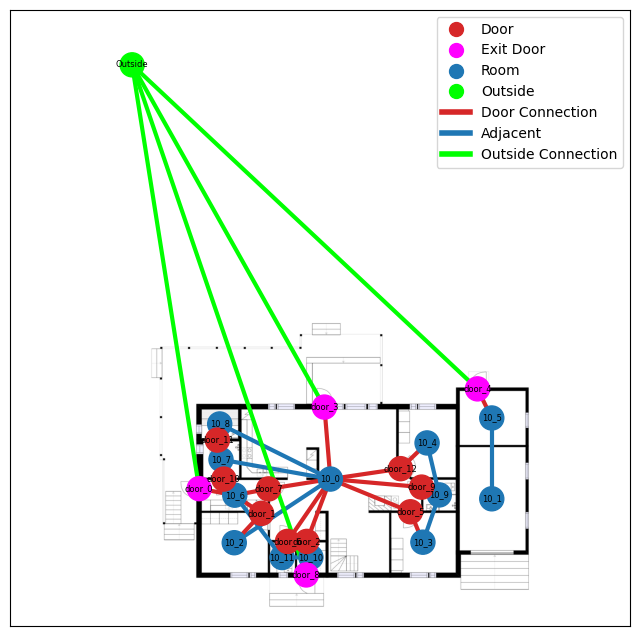

In [10]:
# Make a specific graph from the json data.
plan = 10108
G2Out, img2Out = MakeGraph2(plan,True)
G2, img2 = MakeGraph2(plan,False)

# Plot the Graph, with the floorplan.
GraphPlot(G2Out,plan,img2)